# Week 5 Day 3 Lab

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import minimize

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [3]:
def gradient_descent(derivative, x0, epsilon=0.001, iterations=10000):
    x = x0

    for i in range(iterations):
        slope = derivative(x)

        if slope > 0:
            x = x - epsilon
        elif slope < 0:
            x = x + epsilon
        else: 
            break
    return x

def f(x):
    return x ** 2 + 6 * x + 10

def f_prime(x):
    return 2 * x + 6

min_x = gradient_descent(derivative = f_prime, x0 = 5, epsilon = 0.001, iterations = 20000)

print('Minimum x-values: ', min_x)
print('Minimum function value: ', f(min_x))

Minimum x-values:  -2.9999999999997846
Minimum function value:  1.0


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [4]:
%timeit gradient_descent(f_prime, 5, epsilon = 0.001, iterations = 20000)
%timeit minimize(f, x0 = [5])

%timeit gradient_descent(f_prime, 25, epsilon = 0.001, iterations = 30000)
%timeit minimize(f, x0 = [25])

%timeit gradient_descent(f_prime, -10, epsilon = 0.001, iterations = 30000)
%timeit minimize(f, x0 = [-10])

starting_points = [5, 25, -10]
for start in starting_points:
    gd_result = gradient_descent(f_prime, start, epsilon = 0.001, iterations = 30000)

    scipy_result = minimize(f, x0 = [start])

    print('Starting point: ', start)
    print('Gradient descent minimum: ', gd_result)
    print('SciPy minimum: ', scipy_result.x[0])
    print()

3.88 ms ± 581 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
925 μs ± 41.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.85 ms ± 167 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.12 ms ± 7.68 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
5.26 ms ± 47.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
938 μs ± 70.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Starting point:  5
Gradient descent minimum:  -2.9999999999997846
SciPy minimum:  -2.9999995652413576

Starting point:  25
Gradient descent minimum:  -3.000000000007351
SciPy minimum:  -3.00000083325936

Starting point:  -10
Gradient descent minimum:  -2.999999999999883
SciPy minimum:  -3.000000636935424



### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

Optimization slope:  3.0413797773839772
Optimization intercept:  4.481561544943943
Polyfit slope:  3.0413798020099696
Polyfit intercept:  4.48156143776787
2.28 ms ± 189 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
61 μs ± 427 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


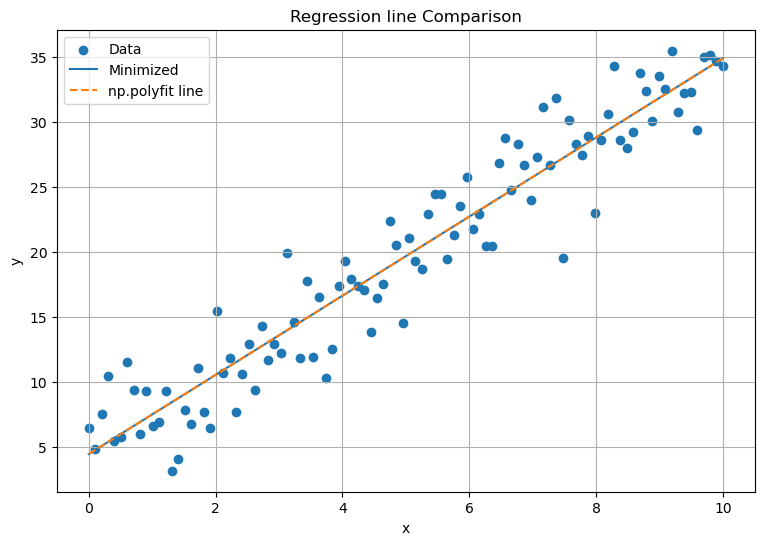

In [6]:
np.random.seed(42)

x_data = np.linspace(0, 10, 100)
y_data = 3 * x_data + 5 + np.random.normal(0, 3, size = len(x_data))

def regression_sse(parameters, x, y):
    slope = parameters[0]
    intercept = parameters[1]

    predictions = slope * x + intercept
    return np. sum((y - predictions) ** 2)

result = minimize(regression_sse, x0 = [0, 0], args = (x_data, y_data))

optimized_slope = result.x[0]
optimized_intercept = result.x[1]

print('Optimization slope: ', optimized_slope)
print('Optimization intercept: ', optimized_intercept)

polyfit_slope, polyfit_intercept = np.polyfit(x_data, y_data, 1)

print('Polyfit slope: ', polyfit_slope)
print('Polyfit intercept: ', polyfit_intercept)

%timeit minimize(regression_sse, x0 = [0, 0], args = (x_data, y_data))
%timeit np.polyfit(x_data, y_data, 1)

optimization_line = (optimized_slope * x_data + optimized_intercept)
polyfit_line = (polyfit_slope * x_data + polyfit_intercept)

plt.figure(figsize=(9, 6))
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_data, optimization_line, label='Minimized')
plt.plot(x_data, polyfit_line, linestyle='--', label='np.polyfit line') 

plt.xlabel('x') 
plt.ylabel('y') 
plt.title('Regression line Comparison') 
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Both methods produce nearly identical regression lines. np.polyfit() is faster but it calculates the least-squares solution,
#while minimize() repeatedly evaluates the loss function while serching for the best slope intercept.

### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

SSE parameters:  [1.90055142 3.75891574]
Absolute error parameters:  [1.90059741 3.75775624]


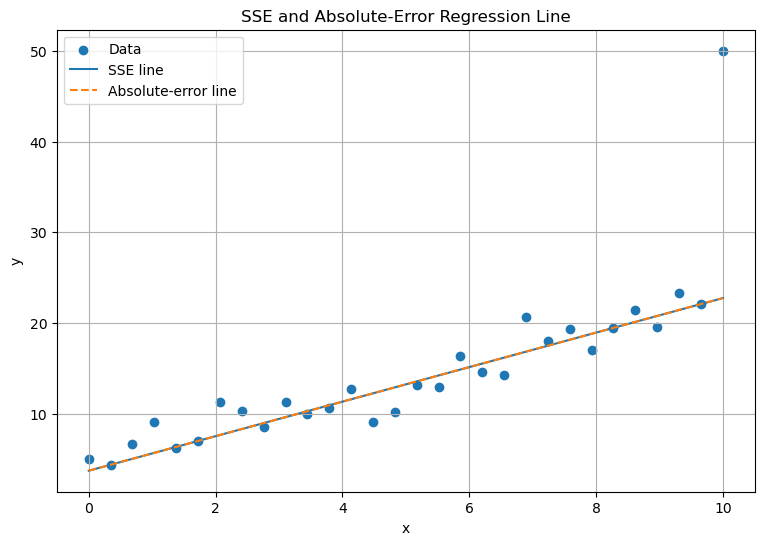

In [7]:
def loss(parameters, x, y):
    slope = parameters[0]
    intercept = parameters[1]

    predictions = slope * x + intercept
    return np.sum((y - predictions) ** 2)

def loss_2(parameters, x, y):
    slope = parameters[0]
    intercept = parameters[1]

    predictions = slope * x + intercept
    return np.sum(np.abs(y - predictions))

np.random.seed(42)

x_example = np.linspace(0, 10, 30)
y_example = 2 * x_example + 4 + np.random.normal(0, 2, size=len(x_example)) 

y_example[-1] = 50

sse_result = minimize(loss_2, x0 = [0, 0], args=(x_example, y_example))
absolute_result = minimize(loss_2, x0 = [0, 0], args=(x_example, y_example), method='Powell')

print('SSE parameters: ', sse_result.x) 
print('Absolute error parameters: ', absolute_result.x) 

sse_line = (sse_result.x[0] * x_example + sse_result.x[1])
absolute_line = (absolute_result.x[0] * x_example + absolute_result.x[1])

plt.figure(figsize=(9, 6))

plt.scatter(x_example, y_example, label='Data')
plt.plot(x_example, sse_line, label='SSE line') 
plt.plot(x_example, absolute_line, linestyle='--', label='Absolute-error line') 

plt.xlabel('x') 
plt.ylabel('y') 
plt.title('SSE and Absolute-Error Regression Line') 
plt.legend()
plt.grid()
plt.show()